# BVD Bridge Response Simulations using Resonance Sweeping

## Do not run: outdated methods

This notebook will focus on the error analysis for solving bridge structures using resonance sweeping, as an alternative to the previously used full audio range sweep. The same structures will be build, to compare results and error landscapes.

First, required modules are imported:

In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager import Bridge

import numpy as np
import matplotlib.pyplot as plt

Next, we iniate our beam libraries and plot the impedance of the beam it containes:

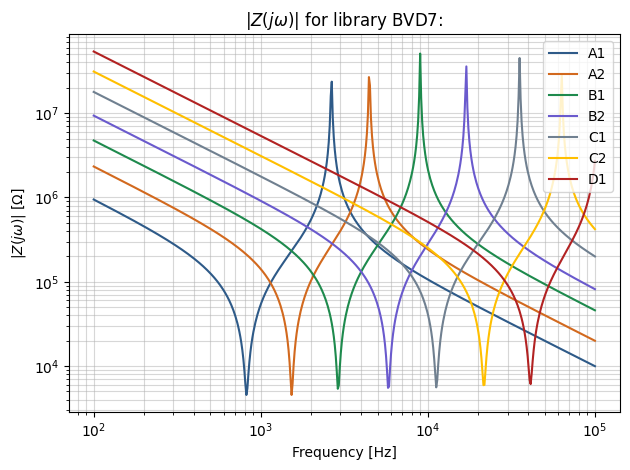

In [2]:
library_name = 'BVD7'
library = open_beam_library(library_name + '.json')

fig, ax = plt.subplots()
colors = ['#2E5A88', '#D2691E', "#1E8A4D", '#6A5ACD', '#708090', '#FFBF00', '#B22222']
f_arr = np.logspace(2, 5, 500)

for beam, color in zip(list(library.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

We will start with the triangle, like before. Since we do not yet have the mydaq succesfully attached, measurement results will be simulated using the extra parameters of the `predict_R` function. Below, the error landscape for the two serial beams is also shown.

Targeting 6 resonant features at (Hz): [ 821.6 1529.3 2071.5 3397.9 6378.8 6690.4]
R-values found, generating plot...
The correct R values were [4500.0, 5250.0, 5250.0], and the solver predicted [4504.6797439  5290.27001103 5238.0676387 ].


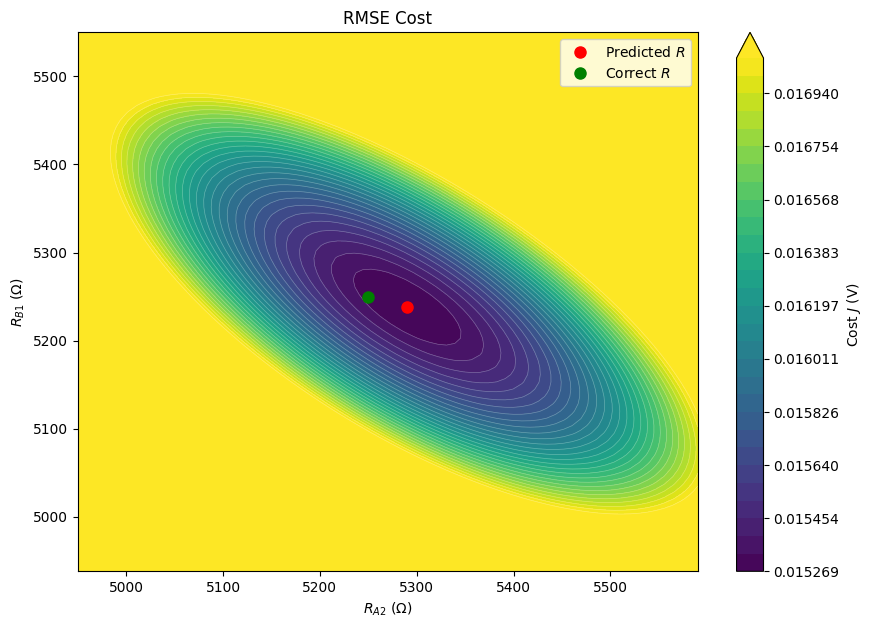

In [3]:
triangle_selection = ['A1', 'A2', 'B1']
triangle_lib = sublibrary(triangle_selection, library)

R_ref = 5e3 # Ohm
U_in = 10 # V
f_logrange = (2, 5) # max frequency sweep between 100 and 100 000 Hz

# Initialize RNG:
rng = np.random.default_rng(seed=42)
sigma = 0.01

# A triangle with A in the floor, B inclined at the left and a C at the right:
triangle_topology = [(0, 2), (0, 1), (1, 2)]
triangle = Bridge()
triangle.construct(triangle_lib, triangle_topology)

# We will predict the R values for a slightly deformed beam:
R_triangle = [4500.0, 5250.0, 5250.0]
R_triangle_pred = triangle.predict_R(U_in, R_ref, R_def=R_triangle, resonance_sweep=True, df=250, freqsteps=1000, add_noise=True, 
                         sigma=sigma, rng=rng, error_plot=True, R_var=[1,2])

print(f'The correct R values were {R_triangle}, and the solver predicted {R_triangle_pred}.')

The bridge frequency response for the triangle can be shown using the method `solve_U`. Below, this is done for both the actual and predicted R values:

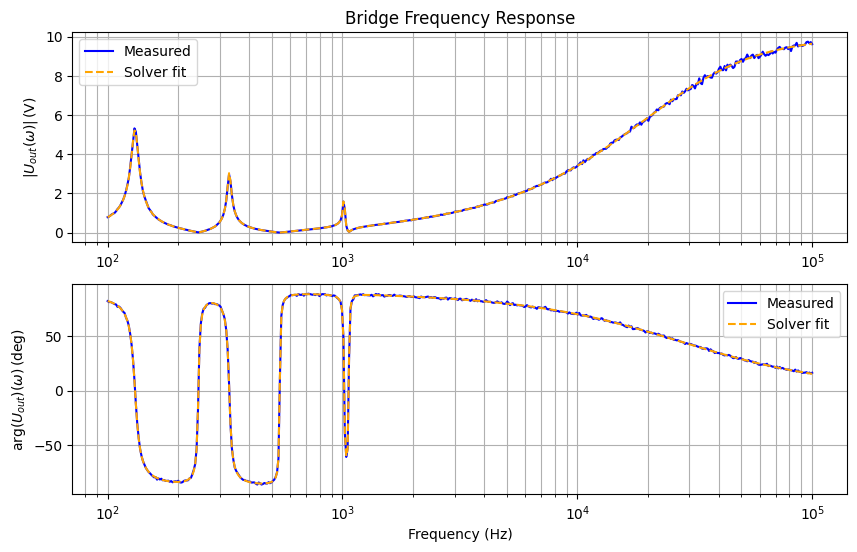

In [4]:
# Plotting:
w_arr = f_arr * 2*np.pi
U_out_mes = triangle.solve_U(w_arr, U_in, R_ref, R_vec=R_triangle, add_noise = True, sigma=sigma, rng=rng)
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_out_pred = triangle.solve_U(w_arr, U_in, R_ref, R_vec=R_triangle_pred, add_noise = False)
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()

We continue by testing the advanted bridge structure, already discussed in previous notebooks. Let's have a look at the predictions for R:

R-values found, generating plot...
The correct R values were [4750.0, 5000.0, 5250.0, 4750.0, 5250.0], and the solver predicted [5473.03068668 5612.12302963 1402.48979552 5069.44495448 5241.09287683].


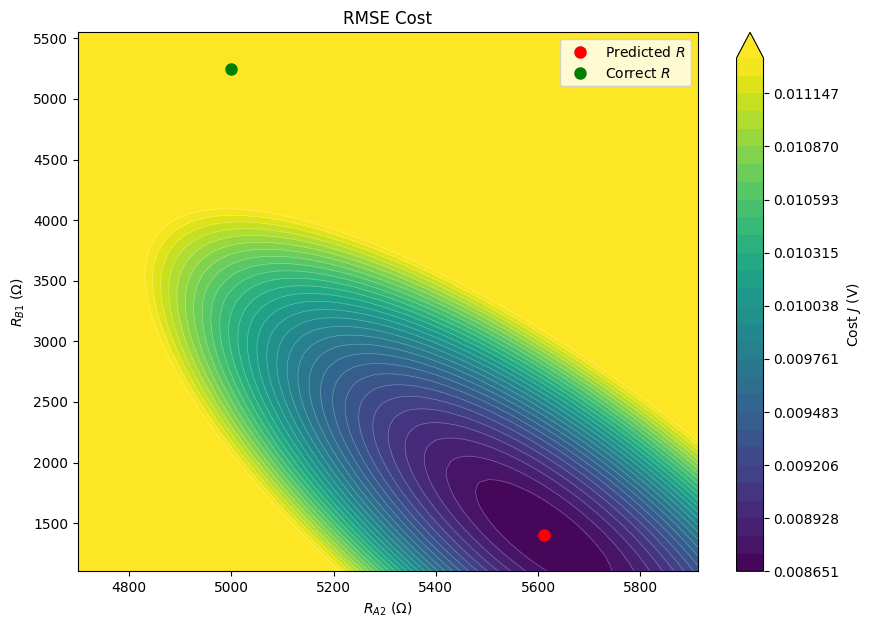

In [ ]:
bridge_selection = ['A1', 'A2', 'B1', 'B2', 'C1']
bridge_lib = sublibrary(bridge_selection, library)

# A more advanced bridge structure:
#    2
# 0  1  3
bridge_topology = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
bridge = Bridge()
bridge.construct(bridge_lib, bridge_topology)

# Let's pretend a force acting on the top node, pointed to the right.
R_bridge = [4750.0, 5000.0, 5250.0, 4750.0, 5250.0]
R_bridge_pred = bridge.predict_R(U_in, R_ref, R_def=R_bridge, resonance_sweep=False, dw=1500, freqsteps=1000, add_noise=True, 
                         sigma=sigma, rng=rng, error_plot=True, R_var=[1,2])

print(f'The correct R values were {R_bridge}, and the solver predicted {R_bridge_pred}.')

For this bridge, the frequency response looks like:

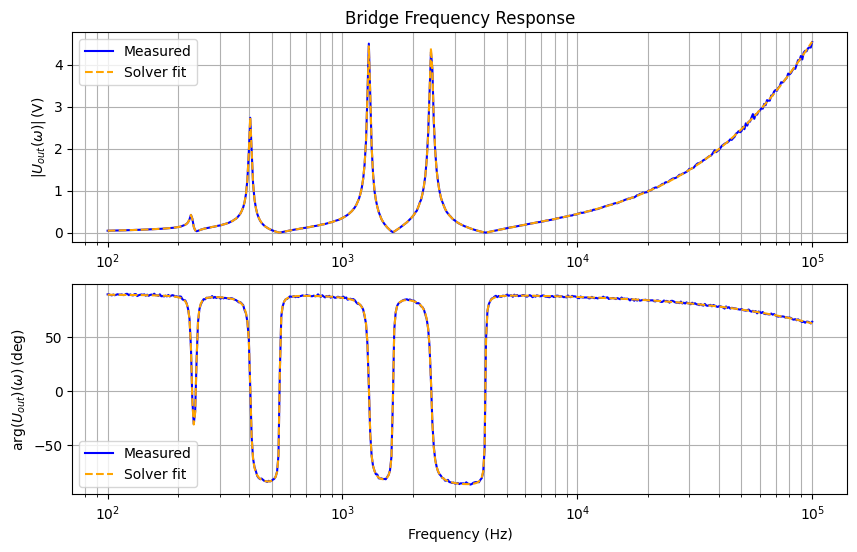

In [6]:
# Plotting:
U_out_mes = bridge.solve_U(w_arr, U_in, R_ref, R_vec=R_bridge, add_noise = True, sigma=sigma, rng=rng)
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_out_pred = bridge.solve_U(w_arr, U_in, R_ref, R_vec=R_bridge_pred, add_noise = False)
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()

Important note: noise makes the phase depths less low!